In [1]:
import utils as ut
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl

In [2]:
nM = ccl.halos.MassFuncTinker08(mass_def='200c')
bM = ccl.halos.HaloBiasTinker10(mass_def='200c')
cM = ut.ConcentrationDutton14(mass_def='200c')
mv2mt = ut.Mvir2MtotNFWt(concentration_f=cM)
pgas = ut.HaloProfileGasBFCDavid(mass_def='200c', log10Mc=14.0, mu=0.74, delta=4.38,
                                 Mvir2Mtot=mv2mt)
pmat = ccl.halos.HaloProfileNFW(mass_def='200c', concentration=cM)

In [3]:
# Define new halo model calculator using the total mass as normalisation of the gas profile
hmc = ccl.halos.HMCalculator(mass_function=nM, halo_bias=bM, mass_def='200c',
                             log10M_min=10.0, log10M_max=15.0, nM=64)

In [4]:
cosmo = ccl.CosmologyVanillaLCDM()

In [5]:
k_arr = np.geomspace(1E-3, 1E2, 100)
lk_arr = np.log(k_arr)
z_arr = np.linspace(0, 2, 16)
a_arr = 1/(1+z_arr[::-1])
pk_mm = ccl.halos.pk_2pt.halomod_Pk2D(cosmo, hmc, pmat, prof2=pmat, lk_arr=lk_arr, a_arr=a_arr)
pk_mg = ccl.halos.pk_2pt.halomod_Pk2D(cosmo, hmc, pmat, prof2=pgas, lk_arr=lk_arr, a_arr=a_arr)
pk_gg = ccl.halos.pk_2pt.halomod_Pk2D(cosmo, hmc, pgas, prof2=pgas, lk_arr=lk_arr, a_arr=a_arr)


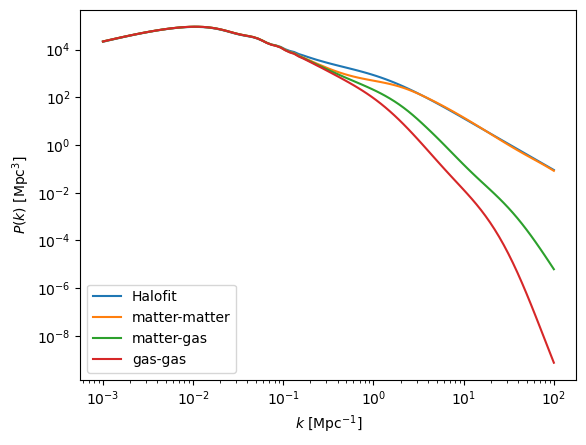

In [6]:
plt.plot(k_arr, cosmo.nonlin_matter_power(k_arr, 1.0), label='Halofit')
plt.plot(k_arr, pk_mm(k_arr, 1.0), label='matter-matter')
plt.plot(k_arr, pk_mg(k_arr, 1.0), label='matter-gas')
plt.plot(k_arr, pk_gg(k_arr, 1.0), label='gas-gas')
plt.loglog()
plt.xlabel(r'$k\,\,[{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)\,\,[{\rm Mpc}^3]$')
plt.legend()
plt.show()

In [7]:
# Cosmology
cosmo = ccl.CosmologyVanillaLCDM()

# Halo model ingredients
nM = ccl.halos.MassFuncTinker08(mass_def='200c')
bM = ccl.halos.HaloBiasTinker10(mass_def='200c')
cM = ut.ConcentrationDutton14(mass_def='200c')
hmc = ccl.halos.HMCalculator(mass_function=nM, halo_bias=bM, mass_def='200c')

# Gas density and electron pressure profiles
Mv2Mt = ut.Mvir2MtotNFWt(concentration_f=cM)
pP = ut.HaloProfilePressureNFWBFCDavid(mass_def='200c',
                                       log10Mc=14.0, mu=1.0,
                                       delta=4, Mvir2Mtot=Mv2Mt)

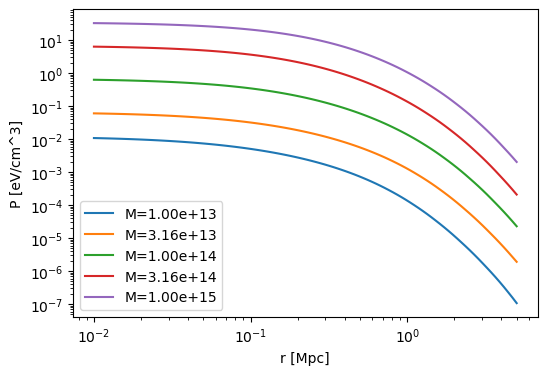

In [8]:
Ms = np.geomspace(1e13, 1e15, 5)
rs = np.geomspace(0.01, 5, 100)

pPr = pP.real(cosmo, rs, Ms, 1.0)
plt.figure(figsize=(6, 4))
for M, P in zip(Ms, pPr):
    plt.plot(rs, P, label=f'M={M:.2e}')
plt.xlabel('r [Mpc]')
plt.ylabel('P [eV/cm^3]')
plt.loglog()
plt.legend()

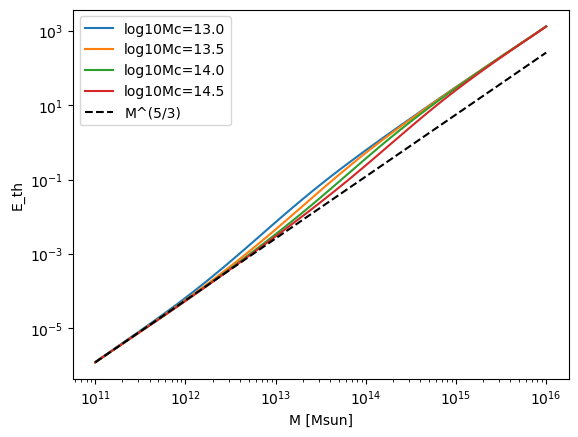

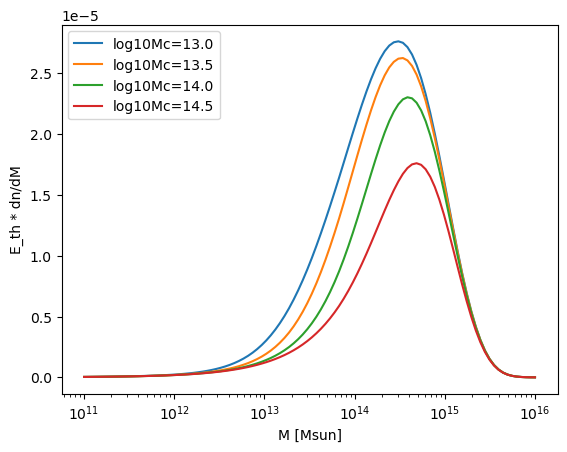

In [9]:
log10Mcs = [13.0, 13.5, 14.0, 14.5]

Ms = np.geomspace(1E11, 1E16, 100)
hmf = nM(cosmo, Ms, 1.0)

plt.figure()
for lMc in log10Mcs:
    pP.update_parameters(log10Mc=lMc)
    Eth = pP.volint(cosmo, 100, Ms, 1.0)
    plt.plot(Ms, Eth, label=f'log10Mc={lMc:.1f}')
plt.plot(Ms, Eth[0]*(Ms/Ms[0])**(5/3), 'k--', label='M^(5/3)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('M')
plt.ylabel('E_th')
plt.xlabel('M [Msun]')
plt.legend()

plt.figure()
for lMc in log10Mcs:
    pP.update_parameters(log10Mc=lMc)
    Eth = pP.volint(cosmo, 100, Ms, 1.0)
    plt.plot(Ms, Eth*hmf, label=f'log10Mc={lMc:.1f}')
plt.xscale('log')
plt.xlabel('M [Msun]')
plt.ylabel('E_th * dn/dM')
plt.legend()

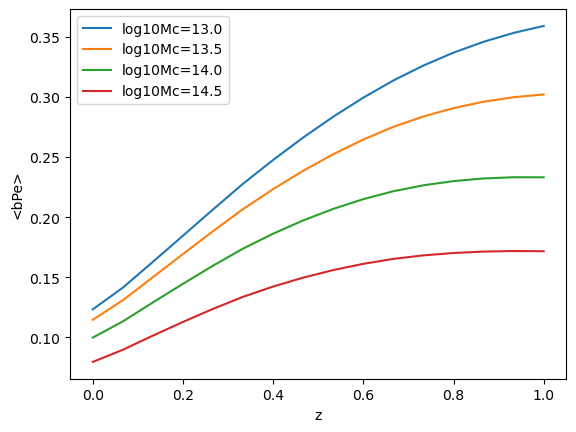

In [10]:
zs = np.linspace(0, 1, 16)

for log10Mc in [13.0, 13.5, 14.0, 14.5]:
    pP.update_parameters(log10Mc=log10Mc)
    bPe = np.array([ut.bU(hmc, pP, z, cosmo) for z in zs])
    plt.plot(zs, 1E3*bPe, label=f'log10Mc={log10Mc:.1f}')
plt.xlabel('z')
plt.ylabel('<bPe>')
plt.legend()